In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#load dataset
df = pd.read_csv("data.csv")

df.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [4]:
df.info()
df.describe()
#Check null values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  object 
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  object 
 5   PaymentMethod       100000 non-null  object 
 6   StoreLocation       100000 non-null  object 
 7   ProductCategory     100000 non-null  object 
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 7.6+ MB


,0
CustomerID,0
ProductID,0
Quantity,0
Price,0
TransactionDate,0
PaymentMethod,0
StoreLocation,0
ProductCategory,0
DiscountApplied(%),0
TotalAmount,0


In [5]:
#check duplicates
df.duplicated().sum()

np.int64(0)

UNIVARIATE ANALYSIS (Single Column)


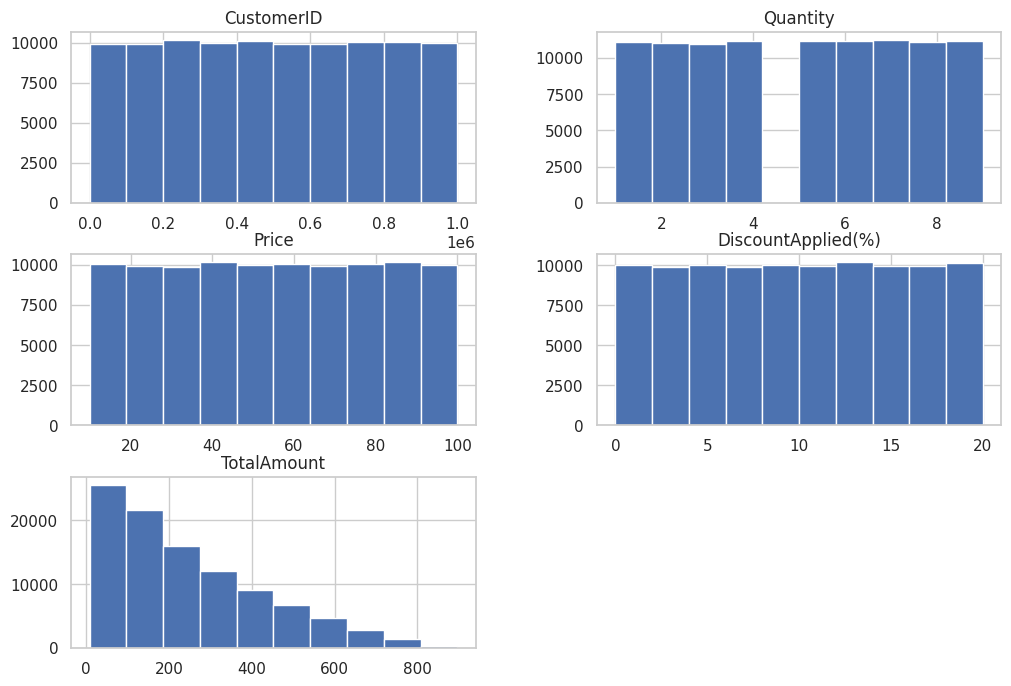

In [6]:
# Distribution of Numerical Features
df.hist(figsize=(12,8))
plt.show()

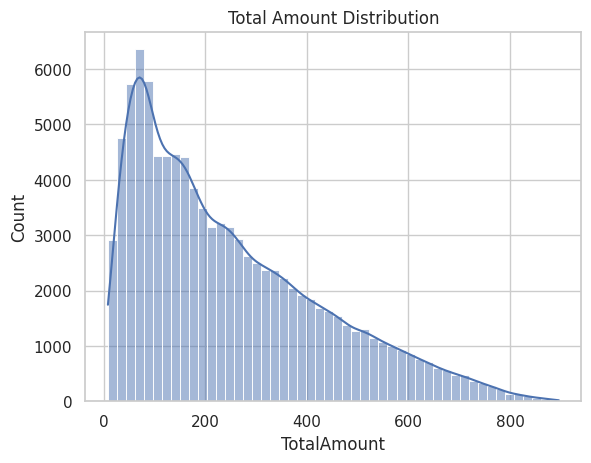

In [11]:
#Total Amount Distribution
sns.histplot(df['TotalAmount'], bins=50, kde=True)
plt.title("Total Amount Distribution")
plt.show()

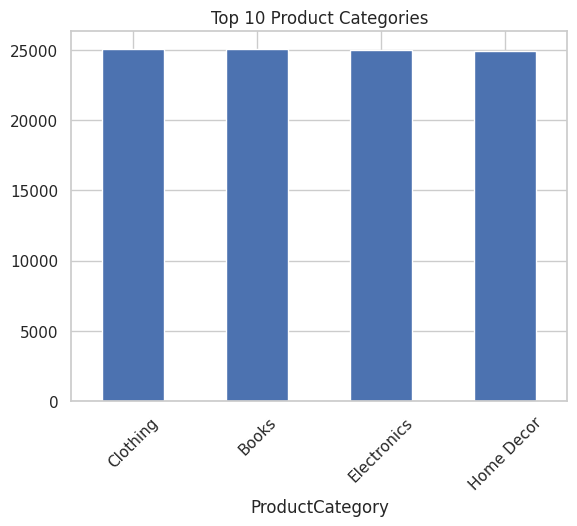

In [13]:
#Product Category Count
top_categories = df['ProductCategory'].value_counts().head(10)

top_categories.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Top 10 Product Categories")
plt.show()

 BIVARIATE ANALYSIS (2 Variables)


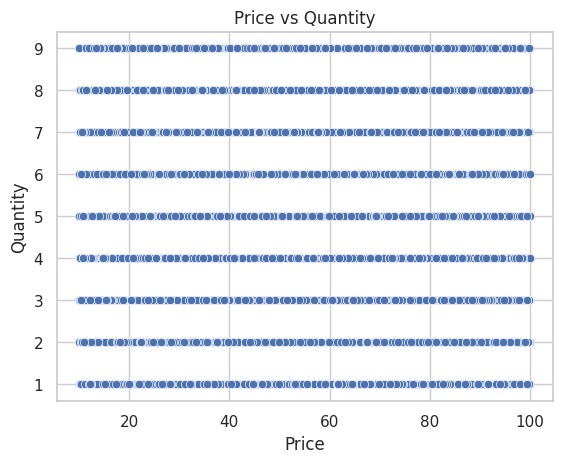

In [14]:
#  Price vs Quantity
sns.scatterplot(x='Price', y='Quantity', data=df)
plt.title("Price vs Quantity")
plt.show()

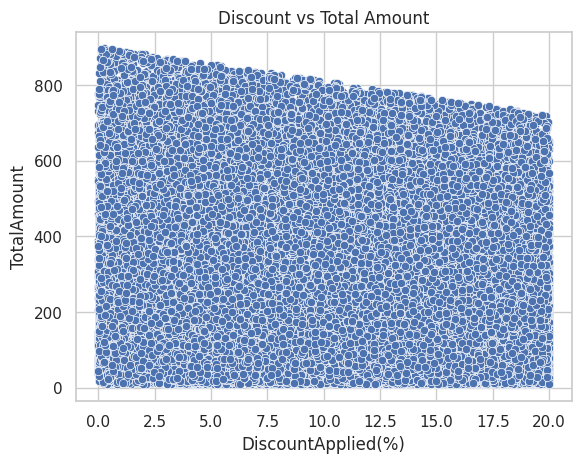

In [17]:
#Discount vs Total Amount
sns.scatterplot(x='DiscountApplied(%)', y='TotalAmount', data=df)
plt.title("Discount vs Total Amount")
plt.show()

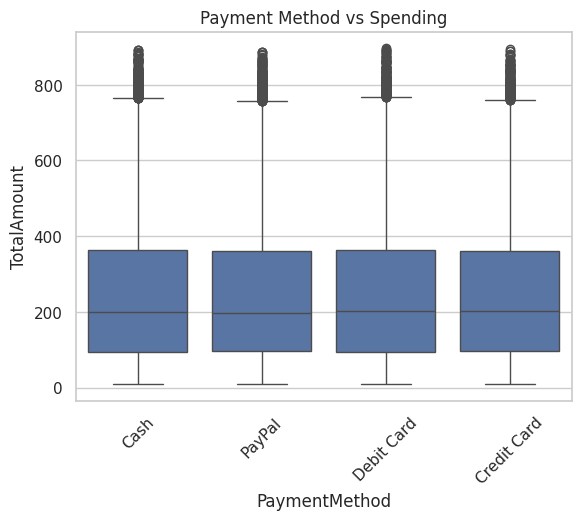

In [19]:
#Payment Method vs Spending
sns.boxplot(x='PaymentMethod', y='TotalAmount', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Spending")
plt.show()

MULTIVARIATE ANALYSIS


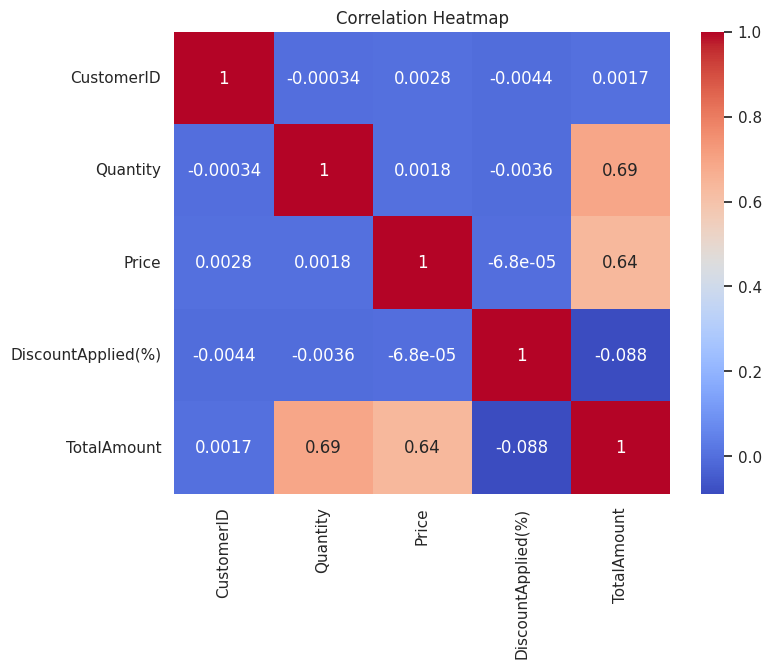

In [20]:
#Correlation Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

TIME-BASED ANALYSIS

In [22]:
#Convert Date Column
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

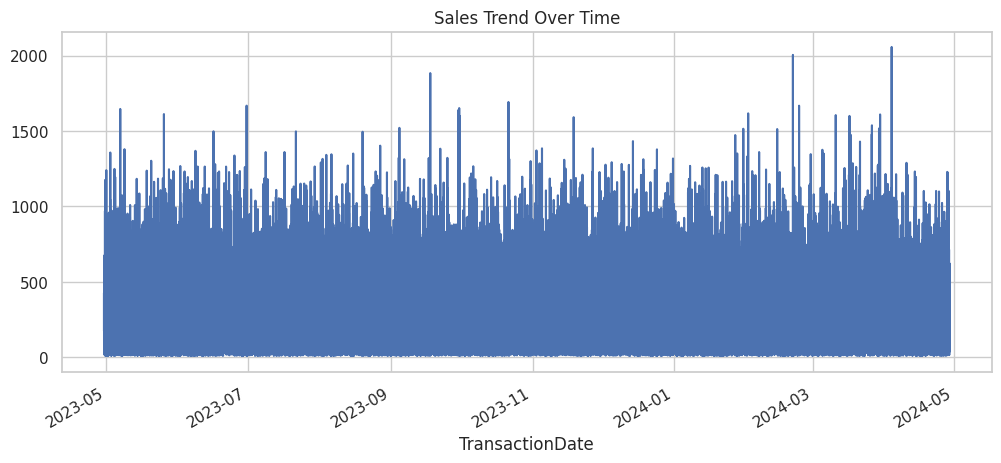

In [24]:
#Sales Over Time
sales_trend = df.groupby('TransactionDate')['TotalAmount'].sum()

sales_trend.plot(figsize=(12,5))
plt.title("Sales Trend Over Time")
plt.show()

CUSTOMER INSIGHTS (IMPORTANT)


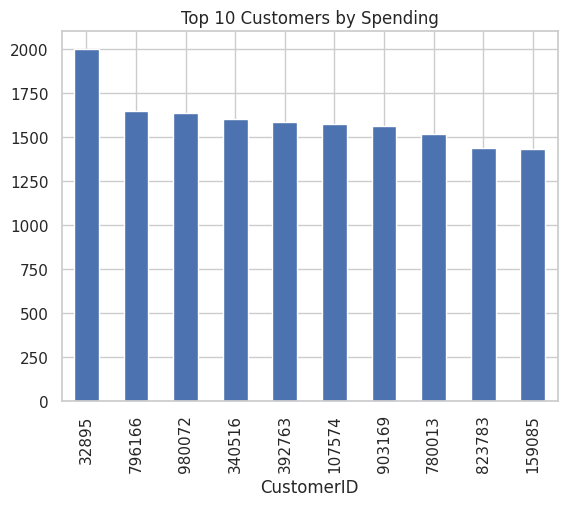

In [26]:
#Top Customers
top_customers = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.show()


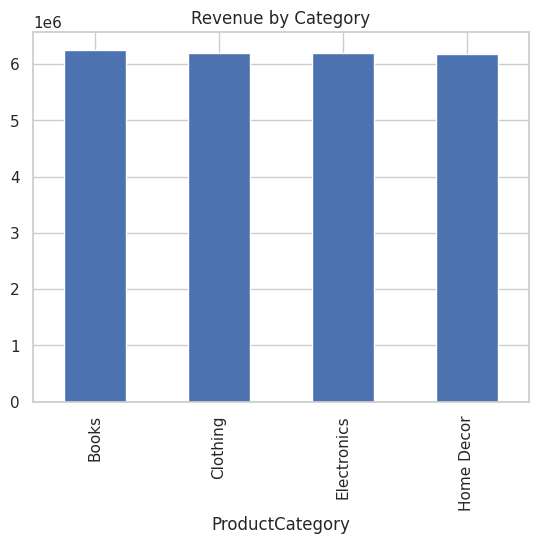

In [28]:
#Category Revenue
category_sales = df.groupby('ProductCategory')['TotalAmount'].sum()

category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

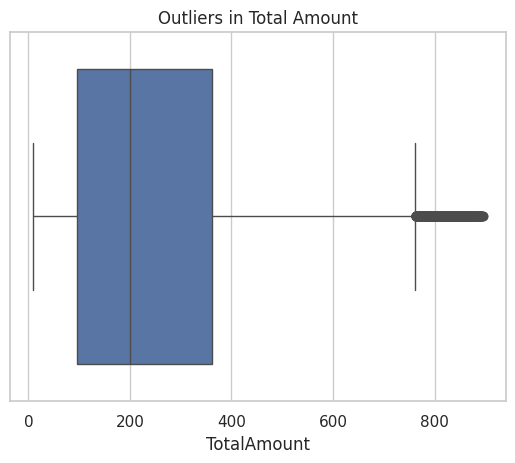

In [29]:
#OUTLIER DETECTION
#Boxplot
sns.boxplot(x=df['TotalAmount'])
plt.title("Outliers in Total Amount")
plt.show()

In [31]:
df.to_csv("eda_checked_data.csv", index=False)